In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, r2_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, roc_auc_score, precision_recall_curve,
    mean_squared_error
)
from sklearn.datasets import fetch_california_housing, load_breast_cancer

# --- dane ---
cancer = load_breast_cancer()
df_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_c['target'] = cancer.target
X_c = df_c[cancer.feature_names]
y_c = df_c['target']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_cs = scaler.fit_transform(X_train_c)
X_test_cs  = scaler.transform(X_test_c)

housing = fetch_california_housing()
df_h = pd.DataFrame(housing.data, columns=housing.feature_names)
df_h['Price'] = housing.target
X_h = df_h.drop(columns=['Price'])
y_h = df_h['Price']
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)


In [2]:
modele_clf = {
    'Regresja logistyczna': LogisticRegression(random_state=42).fit(X_train_cs, y_train_c),
    'Drzewo (depth=3)':     DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train_c, y_train_c),
    'Drzewo (depth=5)':     DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train_c, y_train_c),
    'Drzewo (bez limitu)':  DecisionTreeClassifier(random_state=42).fit(X_train_c, y_train_c),
}
modele_reg = {
    'Regresja liniowa':    LinearRegression().fit(X_train_h, y_train_h),
    'Drzewo (depth=3)':    DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train_h, y_train_h),
    'Drzewo (depth=5)':    DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train_h, y_train_h),
    'Drzewo (bez limitu)': DecisionTreeRegressor(random_state=42).fit(X_train_h, y_train_h),
}
X_map = {'Regresja logistyczna': (X_train_cs, X_test_cs)}

clf_results, reg_results = [], []
for nazwa, model in modele_clf.items():
    X_tr, X_te = X_map.get(nazwa, (X_train_c, X_test_c))
    clf_results.append({'model': nazwa, 'train': accuracy_score(y_train_c, model.predict(X_tr)), 'test': accuracy_score(y_test_c, model.predict(X_te))})
for nazwa, model in modele_reg.items():
    reg_results.append({'model': nazwa, 'train': r2_score(y_train_h, model.predict(X_train_h)), 'test': r2_score(y_test_h, model.predict(X_test_h))})

print("done")

done


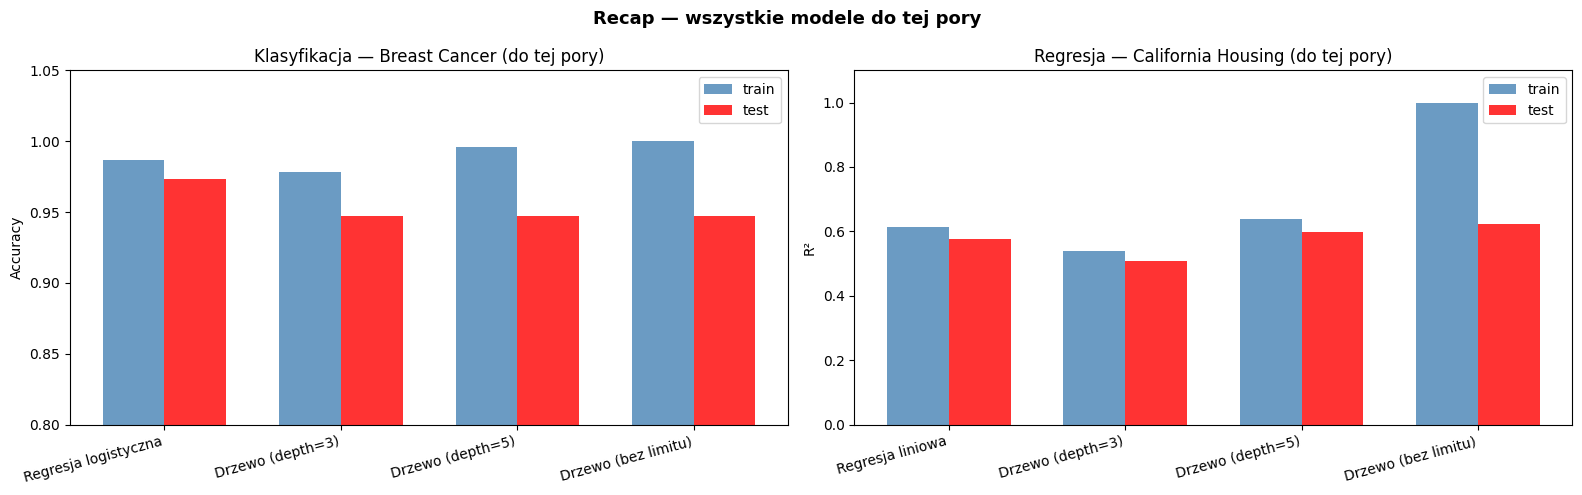

In [3]:
# WIZUALIZACJA RECAP
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
w = 0.35

df_clf = pd.DataFrame(clf_results)
x = range(len(df_clf))
axes[0].bar([i - w/2 for i in x], df_clf['train'], w, label='train', color='steelblue', alpha=0.8)
axes[0].bar([i + w/2 for i in x], df_clf['test'],  w, label='test',  color='red',       alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_clf['model'], rotation=15, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Klasyfikacja — Breast Cancer (do tej pory)')
axes[0].set_ylim(0.8, 1.05)
axes[0].legend()

df_reg = pd.DataFrame(reg_results)
x = range(len(df_reg))
axes[1].bar([i - w/2 for i in x], df_reg['train'], w, label='train', color='steelblue', alpha=0.8)
axes[1].bar([i + w/2 for i in x], df_reg['test'],  w, label='test',  color='red',       alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_reg['model'], rotation=15, ha='right')
axes[1].set_ylabel('R²')
axes[1].set_title('Regresja — California Housing (do tej pory)')
axes[1].set_ylim(0, 1.1)
axes[1].legend()

plt.suptitle('Recap — wszystkie modele do tej pory', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#RANDOM FOREST

In [ ]:
# 🔵 GŁÓWNE — intuicja random forest
# ============================================================
# Pojedyncze drzewo overfittuje — zapamiętuje dane treningowe.
# Co jeśli zamiast jednego drzewa użyjemy 100 drzew?
#
# Dwa mechanizmy które sprawiają że drzewa są różne:
#
# 1. BAGGING (Bootstrap Aggregating)
#    każde drzewo trenuje na losowej próbce danych (ze zwracaniem)
#    każde drzewo widzi trochę inne dane → każde popełnia inne błędy
#
# 2. RANDOM FEATURES
#    przy każdym podziale węzła — nie sprawdzamy wszystkich cech
#    tylko losowy podzbiór cech
#    drzewa są jeszcze bardziej różne od siebie
#
# GŁOSOWANIE
#    klasyfikacja: każde drzewo oddaje głos → wygrywa klasa z większością
#    regresja:     każde drzewo daje predykcję → bierzemy średnią
#
# Błędy poszczególnych drzew się "uśredniają" — losowe błędy znikają
# systematyczne wzorce zostają


In [4]:
# Random Forest klasyfikacja
rf_clf = RandomForestClassifier(
    n_estimators=100,    # liczba drzew. im więcej tym lepiej (ale wolniej)
    max_depth=None,      # każde drzewo rośnie do końca ale las nie overfittuje
    random_state=42
)
rf_clf.fit(X_train_c, y_train_c)

print(f"Random Forest — klasyfikacja:")
print(f"  train accuracy: {accuracy_score(y_train_c, rf_clf.predict(X_train_c)):.4f}")
print(f"  test accuracy:  {accuracy_score(y_test_c,  rf_clf.predict(X_test_c)):.4f}")
print()
print("Drzewo bez limitu miało: train=1.0, test≈0.93")
print("Random Forest:           train=1.0, test=?")
print("Ten sam train=1.0 ale test jest WYŻSZY — las nie overfittuje tak samo!")

Random Forest — klasyfikacja:
  train accuracy: 1.0000
  test accuracy:  0.9649

Drzewo bez limitu miało: train=1.0, test≈0.93
Random Forest:           train=1.0, test=?
Ten sam train=1.0 ale test jest WYŻSZY — las nie overfittuje tak samo!


In [5]:
# 🔵 GŁÓWNE — wpływ liczby drzew
n_trees = [1, 5, 10, 25, 50, 100, 200, 500]
train_scores, test_scores = [], []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_c, y_train_c)
    train_scores.append(accuracy_score(y_train_c, rf.predict(X_train_c)))
    test_scores.append(accuracy_score(y_test_c,  rf.predict(X_test_c)))

print(f"{'n_estimators':>14} {'train':>8} {'test':>8}")
print("-" * 35)
for n, tr, te in zip(n_trees, train_scores, test_scores):
    print(f"{n:>14} {tr:>8.4f} {te:>8.4f}")

  n_estimators    train     test
-----------------------------------
             1   0.9582   0.9386
             5   0.9824   0.9474
            10   0.9978   0.9561
            25   1.0000   0.9649
            50   1.0000   0.9649
           100   1.0000   0.9649
           200   1.0000   0.9649
           500   1.0000   0.9649


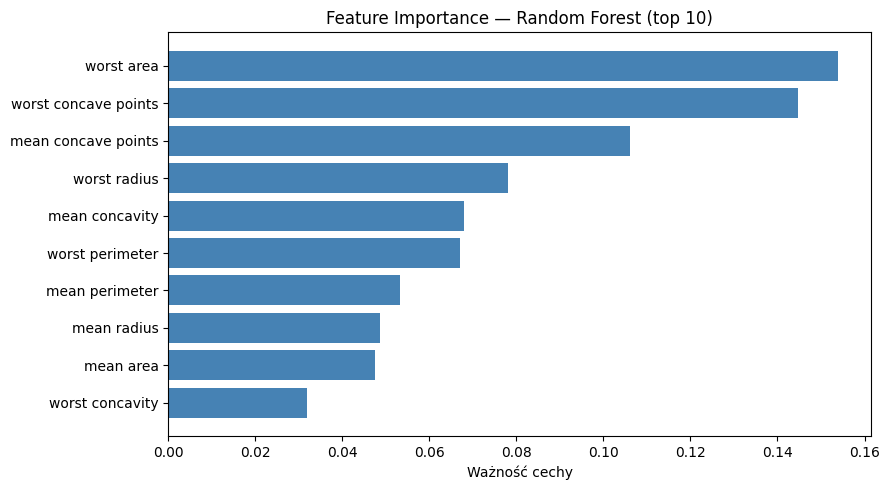

In [6]:
# 🟢 WIZUALIZACJA — feature importance (lepsza niż przy pojedynczym drzewie)
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train_c, y_train_c)

importances = pd.DataFrame({
    'cecha':   cancer.feature_names,
    'ważność': rf_best.feature_importances_
}).sort_values('ważność', ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(importances['cecha'][:10][::-1], importances['ważność'][:10][::-1], color='steelblue')
plt.xlabel('Ważność cechy')
plt.title('Feature Importance — Random Forest (top 10)')
plt.tight_layout()
plt.show()
# bardziej wiarygodna niż przy pojedynczym drzewie —
# uśredniona po 100 drzewach, mniej podatna na przypadkowe wzorce

In [7]:
# Random Forest regresja
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_h, y_train_h)

print(f"Random Forest — regresja:")
print(f"  train R²: {r2_score(y_train_h, rf_reg.predict(X_train_h)):.4f}")
print(f"  test R²:  {r2_score(y_test_h,  rf_reg.predict(X_test_h)):.4f}")

Random Forest — regresja:
  train R²: 0.9736
  test R²:  0.8051


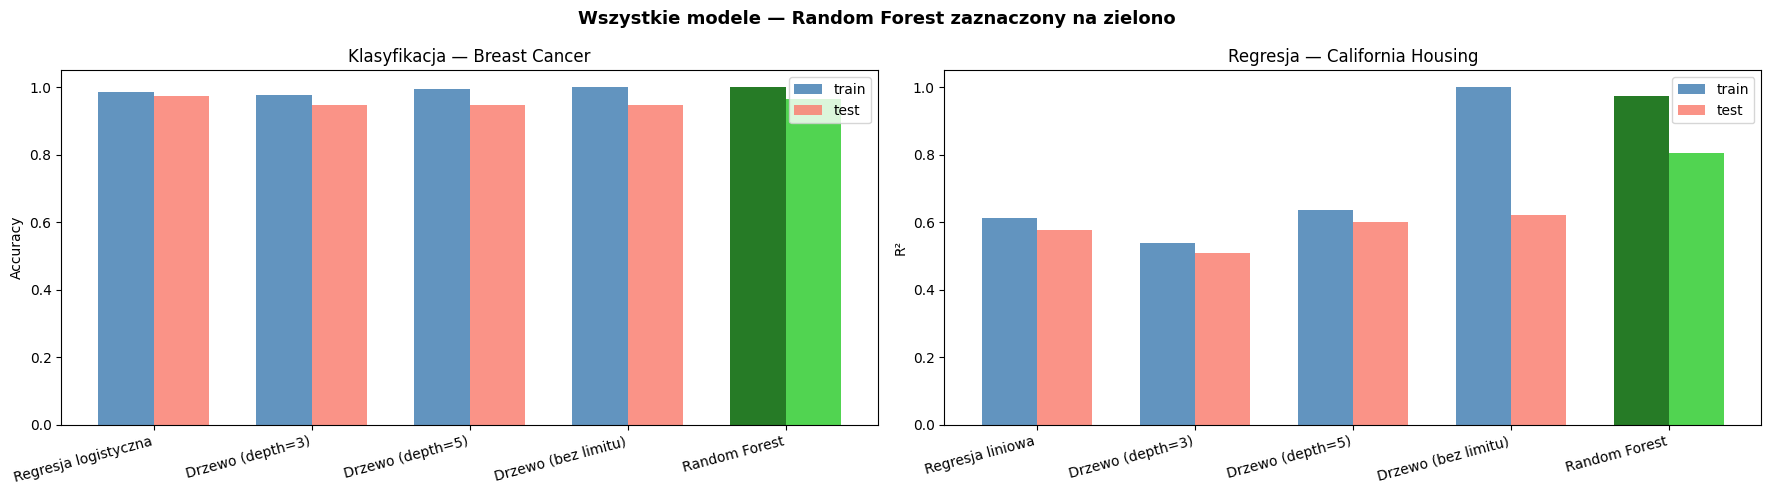

In [8]:
# 🟢 WIZUALIZACJA - porównanie z Random Forest
rf_clf_result = {'model': 'Random Forest', 'train': accuracy_score(y_train_c, rf_clf.predict(X_train_c)), 'test': accuracy_score(y_test_c, rf_clf.predict(X_test_c))}
rf_reg_result = {'model': 'Random Forest', 'train': r2_score(y_train_h, rf_reg.predict(X_train_h)),       'test': r2_score(y_test_h,  rf_reg.predict(X_test_h))}

df_clf2 = pd.DataFrame(clf_results + [rf_clf_result])
df_reg2 = pd.DataFrame(reg_results + [rf_reg_result])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
w = 0.35

colors_train = ['steelblue'] * (len(df_clf2) - 1) + ['darkgreen']
colors_test  = ['salmon']    * (len(df_clf2) - 1) + ['limegreen']

for ax, df, ylabel, title in zip(axes,
    [df_clf2, df_reg2],
    ['Accuracy', 'R²'],
    ['Klasyfikacja — Breast Cancer', 'Regresja — California Housing']):
    x = range(len(df))
    ct = ['steelblue'] * (len(df) - 1) + ['darkgreen']
    ce = ['salmon']    * (len(df) - 1) + ['limegreen']
    ax.bar([i - w/2 for i in x], df['train'], w, color=ct, alpha=0.85, label='train')
    ax.bar([i + w/2 for i in x], df['test'],  w, color=ce, alpha=0.85, label='test')
    ax.set_xticks(x)
    ax.set_xticklabels(df['model'], rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.suptitle('Wszystkie modele — Random Forest zaznaczony na zielono', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

EWALUACJA

In [9]:
# confusion matrix
# TP, FP, TN, FN — co to znaczy w praktyce

y_pred = rf_best.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"  TN (True Negative):  {tn:3d}  → model powiedział złośliwy,  rzeczywiście złośliwy  ✓")
print(f"  FP (False Positive): {fp:3d}  → model powiedział łagodny,   rzeczywiście złośliwy  ✗")
print(f"  FN (False Negative): {fn:3d}  → model powiedział złośliwy,  rzeczywiście łagodny   ✗")
print(f"  TP (True Positive):  {tp:3d}  → model powiedział łagodny,   rzeczywiście łagodny   ✓")
print()
print(f"Accuracy  = (TP+TN) / wszystkie    = ({tp}+{tn}) / {tp+tn+fp+fn} = {(tp+tn)/(tp+tn+fp+fn):.4f}")
print(f"Precision = TP / (TP+FP)           = {tp} / {tp+fp}  = {tp/(tp+fp):.4f}")
print(f"Recall    = TP / (TP+FN)           = {tp} / {tp+fn}  = {tp/(tp+fn):.4f}")

Confusion Matrix:
  TN (True Negative):   40  → model powiedział złośliwy,  rzeczywiście złośliwy  ✓
  FP (False Positive):   3  → model powiedział łagodny,   rzeczywiście złośliwy  ✗
  FN (False Negative):   1  → model powiedział złośliwy,  rzeczywiście łagodny   ✗
  TP (True Positive):   70  → model powiedział łagodny,   rzeczywiście łagodny   ✓

Accuracy  = (TP+TN) / wszystkie    = (70+40) / 114 = 0.9649
Precision = TP / (TP+FP)           = 70 / 73  = 0.9589
Recall    = TP / (TP+FN)           = 70 / 71  = 0.9859


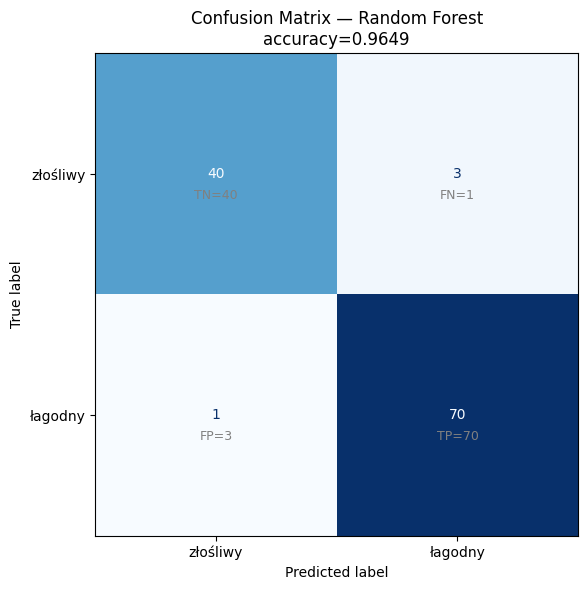

In [10]:
#  WIZUALIZACJA — confusion matrix z opisami
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=['złośliwy', 'łagodny']).plot(ax=ax, cmap='Blues', colorbar=False)

ax.text(0, 0, f'\nTN={tn}', ha='center', va='top', fontsize=9, color='gray')
ax.text(1, 0, f'\nFN={fn}', ha='center', va='top', fontsize=9, color='gray')
ax.text(0, 1, f'\nFP={fp}', ha='center', va='top', fontsize=9, color='gray')
ax.text(1, 1, f'\nTP={tp}', ha='center', va='top', fontsize=9, color='gray')

ax.set_title(f'Confusion Matrix — Random Forest\naccuracy={accuracy_score(y_test_c, y_pred):.4f}')
plt.tight_layout()
plt.show()


In [11]:
# precision vs recall trade-off
# nie można mieć jednocześnie idealnego precision I recall
# zmiana progu decyzji przesuwa balans między nimi

y_prob = rf_best.predict_proba(X_test_c)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
print(f"{'próg':>6} {'precision':>10} {'recall':>8} {'f1':>8} {'fp (zdrowi jako chorzy)':>25} {'fn (chorzy jako zdrowi)':>25}")
print("-" * 90)

for t in thresholds:
    y_t = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test_c, y_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    print(f"{t:>6.1f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {fp_t:>25} {fn_t:>25}")

  próg  precision   recall       f1   fp (zdrowi jako chorzy)   fn (chorzy jako zdrowi)
------------------------------------------------------------------------------------------
   0.2     0.9342   1.0000   0.9660                         5                         0
   0.3     0.9595   1.0000   0.9793                         3                         0
   0.4     0.9589   0.9859   0.9722                         3                         1
   0.5     0.9589   0.9859   0.9722                         3                         1
   0.6     0.9583   0.9718   0.9650                         3                         2
   0.7     0.9583   0.9718   0.9650                         3                         2
   0.8     0.9848   0.9155   0.9489                         1                         6


In [13]:
# krzywa ROC i AUC
fpr, tpr, thresholds_roc = roc_curve(y_test_c, y_prob)
auc = roc_auc_score(y_test_c, y_prob)

print(f"AUC = {auc:.4f}")
print()
print("AUC — Area Under Curve:")
print("  1.0 → idealny model")
print("  0.5 → model losowy (rzut monetą)")
print("  0.0 → model odwrotny (zawsze się myli)")
print()
print("Interpretacja: prawdopodobieństwo że model wyżej oceni")
print("losową próbkę pozytywną niż losową próbkę negatywną")

AUC = 0.9953

AUC — Area Under Curve:
  1.0 → idealny model
  0.5 → model losowy (rzut monetą)
  0.0 → model odwrotny (zawsze się myli)

Interpretacja: prawdopodobieństwo że model wyżej oceni
losową próbkę pozytywną niż losową próbkę negatywną


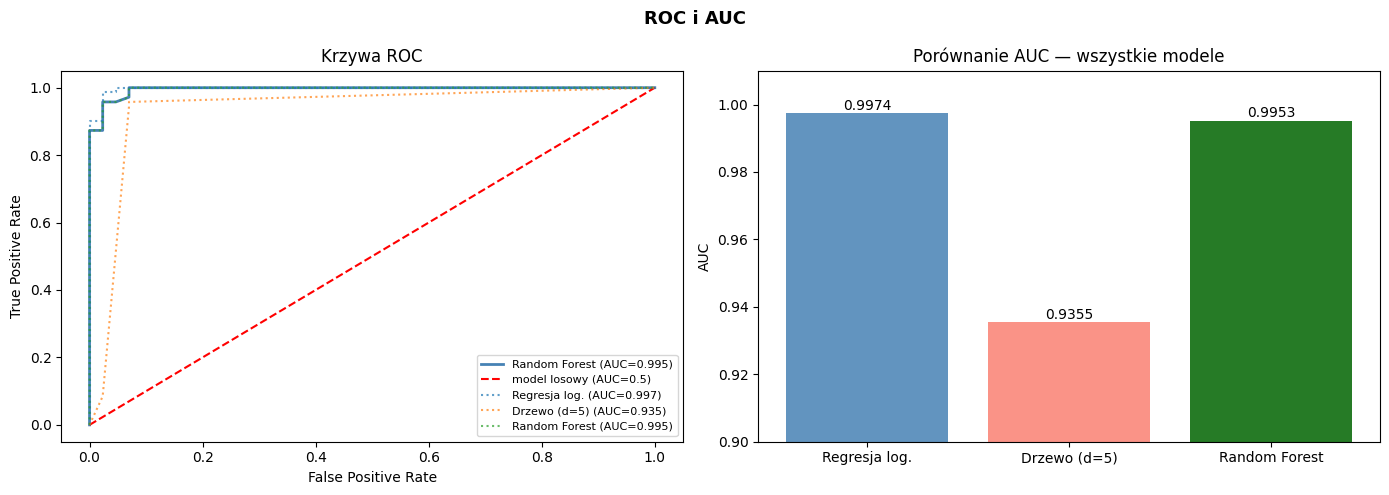

In [14]:
# WIZUALIZACJA — ROC curve porównanie modeli
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Random Forest (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='red', linewidth=1.5, linestyle='--', label='model losowy (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Krzywa ROC')
axes[0].legend()

# porównanie AUC dla wszystkich modeli
modele_auc = {
    'Regresja log.':   LogisticRegression(random_state=42).fit(X_train_cs, y_train_c),
    'Drzewo (d=5)':    DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train_c, y_train_c),
    'Random Forest':   rf_best,
}
X_test_map = {'Regresja log.': X_test_cs}

aucs = []
for nazwa, model in modele_auc.items():
    X_te = X_test_map.get(nazwa, X_test_c)
    prob = model.predict_proba(X_te)[:, 1]
    fpr_m, tpr_m, _ = roc_curve(y_test_c, prob)
    auc_m = roc_auc_score(y_test_c, prob)
    aucs.append(auc_m)
    axes[0].plot(fpr_m, tpr_m, linewidth=1.5, linestyle=':', label=f'{nazwa} (AUC={auc_m:.3f})', alpha=0.7)
axes[0].legend(fontsize=8)

axes[1].bar(modele_auc.keys(), aucs, color=['steelblue', 'salmon', 'darkgreen'], alpha=0.85)
axes[1].set_ylabel('AUC')
axes[1].set_title('Porównanie AUC — wszystkie modele')
axes[1].set_ylim(0.9, 1.01)
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('ROC i AUC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# cross-validation
# Problem z pojedynczym train/test split:
# wynik zależy od tego jak "trafił" podział — może być za optymistyczny lub za pesymistyczny
#
# Cross-validation (k-fold):
# dzielimy dane na k równych części (foldów)
# k razy trenujemy i testujemy — za każdym razem inny fold jest testem
# wynik = średnia z k testów
#
# 5-fold CV:
# fold 1: [TEST][train][train][train][train]
# fold 2: [train][TEST][train][train][train]
# fold 3: [train][train][TEST][train][train]
# fold 4: [train][train][train][TEST][train]
# fold 5: [train][train][train][train][TEST]
# wynik = średnia z 5 testów

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modele_cv = {
    'Regresja logistyczna': (LogisticRegression(random_state=42), X_train_cs),
    'Drzewo (depth=5)':     (DecisionTreeClassifier(max_depth=5, random_state=42), X_train_c),
    'Random Forest':        (RandomForestClassifier(n_estimators=100, random_state=42), X_train_c),
}

print(f"{'Model':25s} {'CV mean':>10} {'CV std':>10}  {'pojedynczy test':>16}")
print("-" * 65)
for nazwa, (model, X_tr) in modele_cv.items():
    scores = cross_val_score(model, X_tr, y_train_c, cv=cv, scoring='accuracy')
    model.fit(X_tr, y_train_c)
    X_te = X_test_cs if nazwa == 'Regresja logistyczna' else X_test_c
    single_test = accuracy_score(y_test_c, model.predict(X_te))
    print(f"{nazwa:25s} {scores.mean():>10.4f} {scores.std():>10.4f}  {single_test:>16.4f}")

print()
print("CV std mówi jak stabilny jest model — niskie std = model konsekwentny")

Model                        CV mean     CV std   pojedynczy test
-----------------------------------------------------------------
Regresja logistyczna          0.9626     0.0179            0.9737
Drzewo (depth=5)              0.9407     0.0256            0.9474
Random Forest                 0.9560     0.0220            0.9649

CV std mówi jak stabilny jest model — niskie std = model konsekwentny


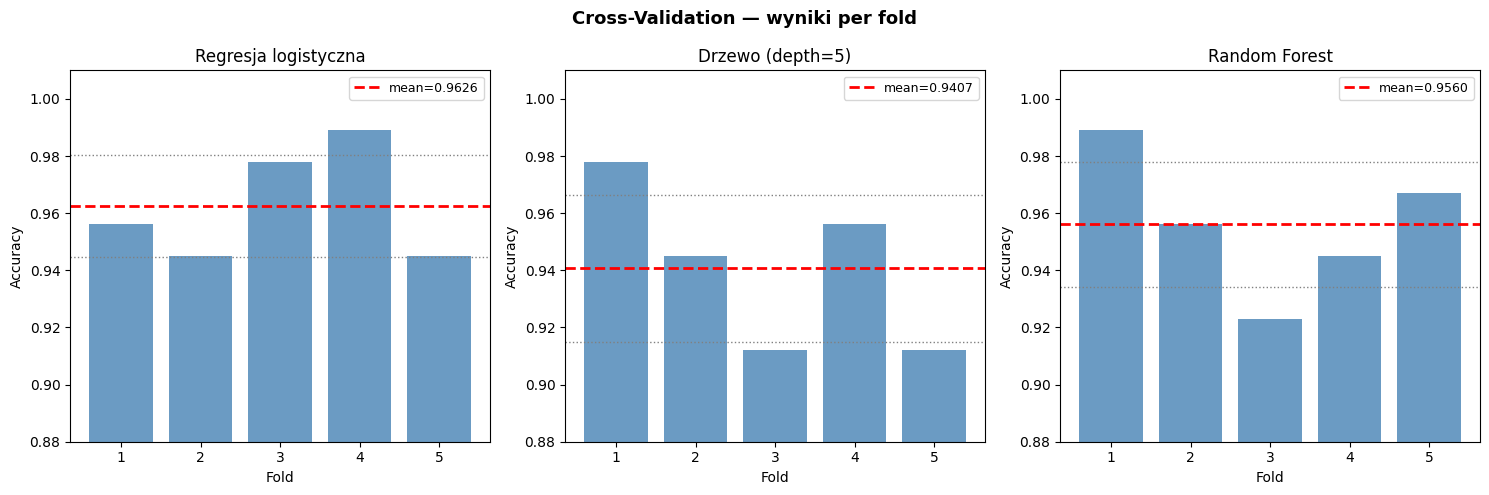

In [16]:
#WIZUALIZACJA — cross-validation wyniki
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (nazwa, (model, X_tr)) in zip(axes, modele_cv.items()):
    scores = cross_val_score(model, X_tr, y_train_c, cv=cv, scoring='accuracy')
    ax.bar(range(1, 6), scores, color='steelblue', alpha=0.8)
    ax.axhline(scores.mean(), color='red', linewidth=2, linestyle='--', label=f'mean={scores.mean():.4f}')
    ax.axhline(scores.mean() + scores.std(), color='gray', linewidth=1, linestyle=':')
    ax.axhline(scores.mean() - scores.std(), color='gray', linewidth=1, linestyle=':')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Accuracy')
    ax.set_title(nazwa)
    ax.set_ylim(0.88, 1.01)
    ax.legend(fontsize=9)

plt.suptitle('Cross-Validation — wyniki per fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()